## Generating a Poem using LangGraph – Trainer Hints (No Code)

### 1. Understand the Goal
- Generate a poem using multiple steps
- Avoid a single LLM call
- Treat poem writing as a workflow

---

### 2. Think in Steps (Nodes)
Ask:
- How does a human write a poem?

Typical steps:
- Understand the topic
- Plan or outline the poem
- Write the poem
- Refine or polish

Each step = one LangGraph node

---

### 3. Define the State
Think about:
- What information moves between nodes?

Possible state items:
- Topic
- Theme or outline
- Draft poem
- Final poem

This shared data becomes the graph state.

---

### 4. Node Responsibility
Each node should:
- Do only one job
- Read from state
- Write back to state

Avoid:
- One node doing everything
- Nodes changing unrelated state

---

### 5. Graph Flow
Decide:
- Linear flow (recommended for beginners)
  - Topic → Draft → Final Poem
- Conditional flow (optional later)
  - If poem is weak, refine

Start simple.

---

### 6. Prompt Thinking
Each node should ask:
- One clear question to the LLM

Examples:
- “Create a poem outline”
- “Write a poem from this outline”
- “Improve rhyme and flow”

Prompt clarity = better output.

---

### 7. Final Output
- Only one node should produce the final poem
- That node writes the final result to state

---

### 8. Why Use LangGraph
LangGraph helps because:
- Steps are separated and visible
- Each stage can be debugged
- Easy to add refinement later
- Supports streaming and inspection

---

### 9. Common Mistakes to Avoid
- One giant node
- Unclear state fields
- Mixing logic across nodes
- Forgetting nodes should be pure (input → output)

---

### 10. Key Trainer Insight
Break poem generation into human-like steps, map each step to a node, and pass results through shared state.


In [10]:
from IPython.core.display import display_jpeg, Image
from langgraph.constants import START, END
import operator

from langchain.chat_models import init_chat_model
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph
from pydantic import BaseModel


##### Define State
class PoemState(TypedDict):
    topic:str
    poem_outline: str
    draft_poem_outline: str
    final_poem: Annotated[list[AnyMessage],operator.add]


##### Define Model
llama_model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)


In [11]:
##### Define Nodes
# topic node
def process_topic(state : PoemState) -> PoemState:
    topic = (f"Create the outline of a poem on topic {state["topic"]}"
             f"Note: Poem should be funny.")
    response = llama_model.invoke(topic)
    # print(">>> poem_outline : ", response.content)
    # print("="*50)

    return {"poem_outline" : response.content}


# poem outline node
def process_poem_outline(state : PoemState) -> PoemState:
    outline = f"Create a outline for the draft funny poem {state["poem_outline"]}"
    response = llama_model.invoke(outline)
    # print(">>> draft_poem_outline : ", response.content)
    # print("="*50)
    return {"draft_poem_outline" : response.content}

# poem final output node
def process_final_poem(state : PoemState) -> PoemState:
    poem_outline = f"polish the funny poem with rhyme from the draft and finalized it within 10 line {state["draft_poem_outline"]}"
    final_poem_response = llama_model.invoke(poem_outline)
    # print(">>> final_poem : ", final_poem_response.content)
    # print("="*50)
    return {"final_poem" : [AIMessage(content=final_poem_response.content)]}


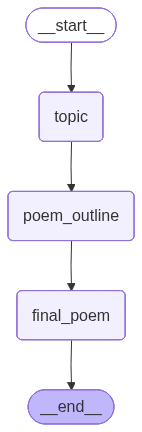

In [12]:

##### Define Graph
graph = StateGraph(PoemState)

graph.add_node("topic",process_topic)
graph.add_node("poem_outline",process_poem_outline)
graph.add_node("final_poem",process_final_poem)

graph.add_edge(START,"topic")
graph.add_edge("topic","poem_outline")
graph.add_edge("poem_outline","final_poem")
graph.add_edge("final_poem",END)

agent = graph.compile()

##### display agent flow
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [13]:
##### Provide prompt
prompt = {
    "topic" : "ENGINEER"
}

##### Invoke the prompt to the agent
final_response = agent.invoke(prompt)
print(final_response["final_poem"][0].content)

Here's a polished version of the funny poem within 10 lines:

The Engineer's Dilemma

With formulas and codes, they rule the land,
Their love for numbers is a never-ending plan.
They calculate the best way to eat a sandwich, it's a feat,
And optimize the route to the fridge, a true feat.

Their obsession with efficiency is a never-ending quest,
They build a machine to make a cup of coffee, it's a test.
Their lack of social skills is a tragic, sad tale,
They think a party invitation is a math problem to hail.
They calculate the best way to take a nap, but forget to play,
Their love for numbers is a never-ending plan, every single day.
